In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
import datetime
from tqdm import tqdm

import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
input_df=pd.read_csv('query.csv', sep=",")
input_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2000-01-01T11:02:45.470Z,51.7110,179.1880,94.7,4.2,mb,NaN,NaN,NaN,0.81,...,2014-11-07T01:09:15.286Z,"288 km W of Adak, Alaska",earthquake,NaN,NaN,NaN,3.0,reviewed,us,us
1,2000-01-02T02:02:43.440Z,47.6050,154.4230,33.0,4.2,mb,NaN,NaN,NaN,0.74,...,2014-11-07T01:09:15.981Z,Kuril Islands,earthquake,NaN,NaN,NaN,8.0,reviewed,us,us
2,2000-01-02T12:58:42.300Z,51.4470,-175.5580,33.0,5.8,mwc,NaN,NaN,NaN,0.98,...,2022-04-29T19:41:46.008Z,"88 km ESE of Adak, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
3,2000-01-02T17:25:30.850Z,51.4990,-175.5200,33.0,5.2,mwc,NaN,NaN,NaN,1.12,...,2022-04-29T17:49:39.971Z,"87 km ESE of Adak, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
4,2000-01-03T16:34:58.480Z,45.1350,148.2380,111.4,4.1,mb,NaN,NaN,NaN,0.80,...,2014-11-07T01:09:16.874Z,"30 km ESE of Kuril’sk, Russia",earthquake,NaN,18.000,NaN,2.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086,2025-08-12T03:34:45.650Z,49.7488,157.9351,10.0,4.5,mb,21.0,176.0,3.310,0.90,...,2025-08-12T05:02:41.040Z,"165 km SE of Severo-Kuril’sk, Russia",earthquake,13.48,1.971,0.087,39.0,reviewed,us,us
16087,2025-08-12T04:15:49.256Z,50.1018,156.9500,35.0,4.7,mb,69.0,127.0,3.047,0.60,...,2025-08-12T05:15:53.040Z,"86 km SE of Severo-Kuril’sk, Russia",earthquake,5.05,1.914,0.048,130.0,reviewed,us,us
16088,2025-08-12T07:28:15.206Z,51.2906,159.1447,10.0,4.8,mb,48.0,122.0,1.762,0.96,...,2025-08-12T07:56:30.040Z,"185 km E of Ozernovskiy, Russia",earthquake,9.62,1.888,0.039,199.0,reviewed,us,us
16089,2025-08-12T08:22:28.000Z,51.0696,160.7074,10.0,4.8,mb,69.0,172.0,2.333,0.77,...,2025-08-12T09:06:21.040Z,"260 km SE of Vilyuchinsk, Russia",earthquake,6.22,1.824,0.030,337.0,reviewed,us,us


In [ ]:
df = pd.DataFrame()
df['Mag']=input_df['mag'].astype(float)
df['Lat']=input_df['latitude'].astype(float)
df['Long']=input_df['longitude'].astype(float)
df['Date']=pd.to_datetime(input_df.time).dt.date
df['Timestamp']=pd.to_datetime(input_df.time)
df['Deep']=input_df['depth'].astype(float)
df

,Mag,Lat,Long,Date,Timestamp,Deep
0,4.2,51.7110,179.1880,2000-01-01,2000-01-01 11:02:45.470000+00:00,94.7
1,4.2,47.6050,154.4230,2000-01-02,2000-01-02 02:02:43.440000+00:00,33.0
2,5.8,51.4470,-175.5580,2000-01-02,2000-01-02 12:58:42.300000+00:00,33.0
3,5.2,51.4990,-175.5200,2000-01-02,2000-01-02 17:25:30.850000+00:00,33.0
4,4.1,45.1350,148.2380,2000-01-03,2000-01-03 16:34:58.480000+00:00,111.4
...,...,...,...,...,...,...
16086,4.5,49.7488,157.9351,2025-08-12,2025-08-12 03:34:45.650000+00:00,10.0
16087,4.7,50.1018,156.9500,2025-08-12,2025-08-12 04:15:49.256000+00:00,35.0
16088,4.8,51.2906,159.1447,2025-08-12,2025-08-12 07:28:15.206000+00:00,10.0
16089,4.8,51.0696,160.7074,2025-08-12,2025-08-12 08:22:28+00:00,10.0


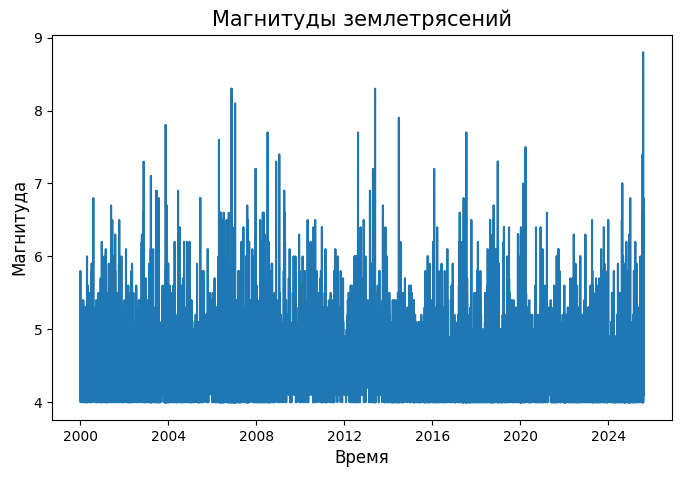

In [ ]:
plt.figure(figsize = [8, 5])

plt.plot(df.Date,df.Mag)

# Format title and axis labels
plt.title("Магнитуды землетрясений", fontsize = 15)
plt.xlabel("Время", fontsize = 12)
plt.ylabel("Магнитуда", fontsize = 12)
plt.show()

In [ ]:
df['Long']=df['Long']%360

In [ ]:
minlong=df.Long.min()
maxlong=df.Long.max()
print(minlong, maxlong)
minlat=df.Lat.min()
maxlat=df.Lat.max()
print(minlat, maxlat)

137.8828 184.5694
44.138 64.067


In [ ]:
df['Long']=(df['Long']-minlong)/(maxlong-minlong)
df['Lat']=(df['Lat']-minlat)/(maxlat-minlat)

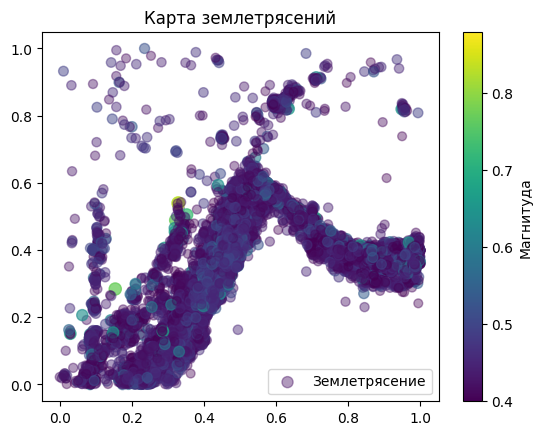

In [ ]:
ax = plt.gca()

scatter = ax.scatter(x=df["Long"], y=df["Lat"],
                    s=df['Mag']/0.1,
                    c=df['Mag']/10,
                    alpha=df['Mag']/10,
                    label="Землетрясение")

cbar = plt.colorbar(scatter)
cbar.set_label('Магнитуда')

plt.title('Карта землетрясений')
plt.legend()
plt.show()

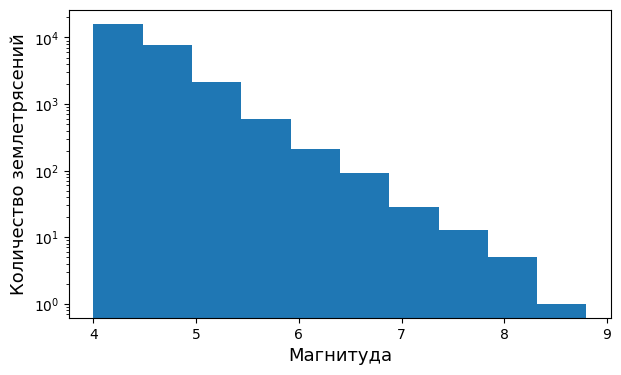

In [ ]:
plt.figure(figsize = [7, 4])


plt.hist(np.array(df.Mag), log=True, cumulative=-1)
plt.xlabel("Магнитуда", fontsize = 13)
plt.ylabel("Количество землетрясений", fontsize = 13)
plt.show()

In [ ]:
def get_area(row):
    lat_norm = row['Lat']
    long_norm = row['Long']

    if lat_norm <= 0.5 and long_norm <= 0.5:
        return 1
    elif lat_norm <= 0.5 and long_norm > 0.5:
        return 2
    elif lat_norm > 0.5 and long_norm <= 0.5:
        return 3
    else:
        return 4
df['area'] = df.apply(get_area, axis=1)
area_agg = df.groupby(['Date', 'area'])['Mag'].max().unstack(fill_value=0)
area_agg.columns = [f'mag_max_area_{k}' for k in area_agg.columns]

In [ ]:
df_daily = df.groupby('Date').agg(max_mag=('Mag','max'), mag_mean=('Mag','mean'),
                                  mag_sum=('Mag','sum') ,num_events=('Mag','count'),
                                  mean_lat=('Lat','mean'), mean_long=('Long','mean'),
                                  mean_deep=('Deep','mean'))
df_daily = df_daily.join(area_agg)
min_date = df['Date'].min()
max_date = df['Date'].max()
full_dates = pd.date_range(start=min_date, end=max_date, freq='D')
df_daily = df_daily.reindex(full_dates, fill_value=0)

df_daily['target'] = np.where(df_daily['max_mag']>=6, 1, 0)
df_daily

,max_mag,mag_mean,mag_sum,num_events,mean_lat,mean_long,mean_deep,mag_max_area_1,mag_max_area_2,mag_max_area_3,mag_max_area_4,target
2000-01-01,4.2,4.200000,4.2,1,0.379999,0.884734,94.700000,0.0,4.2,0.0,0.0,0
2000-01-02,5.8,5.066667,15.2,3,0.303360,0.783213,33.000000,4.2,5.8,0.0,0.0,0
2000-01-03,4.1,4.100000,4.1,1,0.050028,0.221802,111.400000,4.1,0.0,0.0,0.0,0
2000-01-04,4.1,4.100000,4.1,1,0.345226,0.793894,33.000000,0.0,4.1,0.0,0.0,0
2000-01-05,4.0,4.000000,4.0,1,0.352602,0.881092,33.000000,0.0,4.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-08,5.0,4.684211,89.0,19,0.341670,0.434905,44.475737,5.0,0.0,0.0,0.0,0
2025-08-09,6.0,4.655556,125.7,27,0.333070,0.442141,33.421963,6.0,0.0,0.0,0.0,1
2025-08-10,5.3,4.627778,83.3,18,0.385369,0.461117,53.202389,5.3,4.3,0.0,0.0,0
2025-08-11,5.2,4.640000,69.6,15,0.396238,0.493815,29.874333,5.2,4.5,0.0,4.2,0


In [ ]:
df_daily['mag_roll_4'] = df_daily.max_mag.rolling(window=4, min_periods=1).mean()
df_daily['mag_roll_30'] = df_daily.max_mag.rolling(window=30, min_periods=1).mean()
df_daily['mag_roll_max_30'] = df_daily.max_mag.rolling(window=30, min_periods=1).max()
df_daily

,max_mag,mag_mean,mag_sum,num_events,mean_lat,mean_long,mean_deep,mag_max_area_1,mag_max_area_2,mag_max_area_3,mag_max_area_4,target,mag_roll_4,mag_roll_30,mag_roll_max_30
2000-01-01,4.2,4.200000,4.2,1,0.379999,0.884734,94.700000,0.0,4.2,0.0,0.0,0,4.200,4.200000,4.2
2000-01-02,5.8,5.066667,15.2,3,0.303360,0.783213,33.000000,4.2,5.8,0.0,0.0,0,5.000,5.000000,5.8
2000-01-03,4.1,4.100000,4.1,1,0.050028,0.221802,111.400000,4.1,0.0,0.0,0.0,0,4.700,4.700000,5.8
2000-01-04,4.1,4.100000,4.1,1,0.345226,0.793894,33.000000,0.0,4.1,0.0,0.0,0,4.550,4.550000,5.8
2000-01-05,4.0,4.000000,4.0,1,0.352602,0.881092,33.000000,0.0,4.0,0.0,0.0,0,4.500,4.440000,5.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-08,5.0,4.684211,89.0,19,0.341670,0.434905,44.475737,5.0,0.0,0.0,0.0,0,5.300,5.040000,8.8
2025-08-09,6.0,4.655556,125.7,27,0.333070,0.442141,33.421963,6.0,0.0,0.0,0.0,1,5.500,5.086667,8.8
2025-08-10,5.3,4.627778,83.3,18,0.385369,0.461117,53.202389,5.3,4.3,0.0,0.0,0,5.375,5.113333,8.8
2025-08-11,5.2,4.640000,69.6,15,0.396238,0.493815,29.874333,5.2,4.5,0.0,4.2,0,5.375,5.113333,8.8


<Axes: >

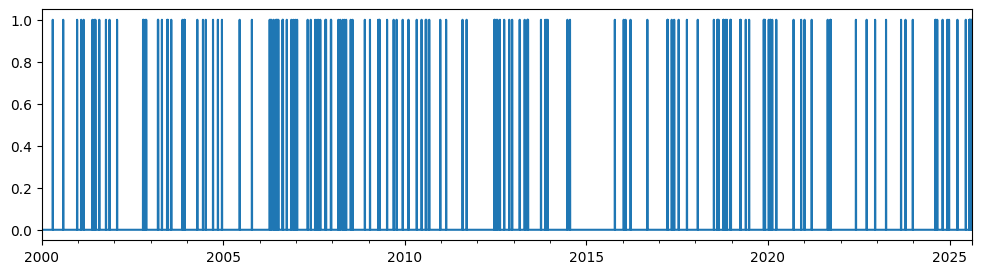

In [ ]:
df_daily['target'].plot(figsize=(12,3))

Составление обучающей и тестовой выборок (без валидационной)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
WINDOW_SIZE = 200 #Размер окна для предсказания (в днях)

features = list(df_daily.columns)
features.remove('target')
target = 'target'


# Функция для создания окон
def create_sequences(data, targets, window_size, train_perc):
    X_train, y_train, X_test, y_test = [], [], [], []
    train_size = round(len(data) * train_perc)
    for i in range(train_size - window_size):
        X_train.append(data[i:(i + window_size)])
        y_train.append(targets[i + window_size])
    for i in range(train_size - window_size, len(data) - window_size):
        X_test.append(data[i:(i + window_size)])
        y_test.append(targets[i + window_size])
    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

# Формируем окна из исходных данных
X_train, y_train, X_test, y_test = create_sequences(df_daily[features].values, df_daily[target].values, window_size=WINDOW_SIZE, train_perc=0.9)

nsamples, nwindow, nfeatures = X_train.shape
scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, nfeatures)
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_train_scaled = X_train_scaled_2d.reshape(nsamples, nwindow, nfeatures)

X_test_2d = X_test.reshape(-1, nfeatures)
X_test_scaled_2d = scaler.transform(X_test_2d)
X_test_scaled = X_test_scaled_2d.reshape(X_test.shape)


X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                         generator=torch.Generator().manual_seed(42))

In [ ]:
pd.Series(y_train).value_counts()

,count
0,8064
1,156


In [ ]:
pd.Series(y_test).value_counts()

,count
0,912
1,24


In [ ]:
class EarthquakeLSTM(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, bidirectional=True, dropout=0.1, num_heads=4):
        super(EarthquakeLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM слой
        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0 if num_layers == 1 else dropout  # Dropout только если num_layers > 1
        )

        # Self-Attention слой
        embed_dim = hidden_size * 2 if bidirectional else hidden_size
        self.attention = torch.nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # Полносвязные слои
        self.dropout = torch.nn.Dropout(dropout)
        self.fc1 = torch.nn.Linear(embed_dim, hidden_size)
        self.act1 = torch.nn.LeakyReLU(0.1)
        self.fc2 = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        # LSTM слой
        out, _ = self.lstm(x)  # out: (batch_size, seq_len, embed_dim)

        # Self-Attention: применяем внимание к выходам LSTM
        attn_out, _ = self.attention(out, out, out)  # attn_out: (batch_size, seq_len, embed_dim)
        out = out + attn_out

        out = self.dropout(out[:, -1, :])  # (batch_size, embed_dim)

        # Полносвязные слои
        out = self.fc1(out)
        out = self.act1(out)
        out = self.fc2(out)
        out = torch.sigmoid(out)

        return out.squeeze()

model = EarthquakeLSTM(input_size=len(features), hidden_size = 64, num_layers = 3, num_heads = 16).to(device)
print(model)

EarthquakeLSTM(
  (lstm): LSTM(14, 64, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (act1): LeakyReLU(negative_slope=0.1)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
class_weights = torch.tensor([1.0, len(y_train)/(2*np.sum(y_train))], device=device) # Веса классов (т.к. сильный дисбаланс)
criterion = torch.nn.BCELoss(weight=class_weights[1] if len(class_weights) > 1 else None) # Бинарная кросс-энтропия с поправкой
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)

num_epochs = 100
train_losses = []

model.train()
for epoch in tqdm(range(num_epochs), desc=f"Progress:"):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if epoch%10==0:
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Progress::   2%|▏         | 1/50 [00:03<03:03,  3.75s/it]

Epoch [1/50], Loss: 2.9964


Progress::  12%|█▏        | 6/50 [00:22<02:46,  3.79s/it]

Epoch [6/50], Loss: 2.5813


Progress::  22%|██▏       | 11/50 [00:41<02:27,  3.79s/it]

...

Progress::  82%|████████▏ | 41/50 [02:33<00:33,  3.74s/it]

Epoch [41/50], Loss: 2.3478


Progress::  92%|█████████▏| 46/50 [02:52<00:14,  3.72s/it]

Epoch [46/50], Loss: 2.3660


Progress:: 100%|██████████| 50/50 [03:07<00:00,  3.74s/it]


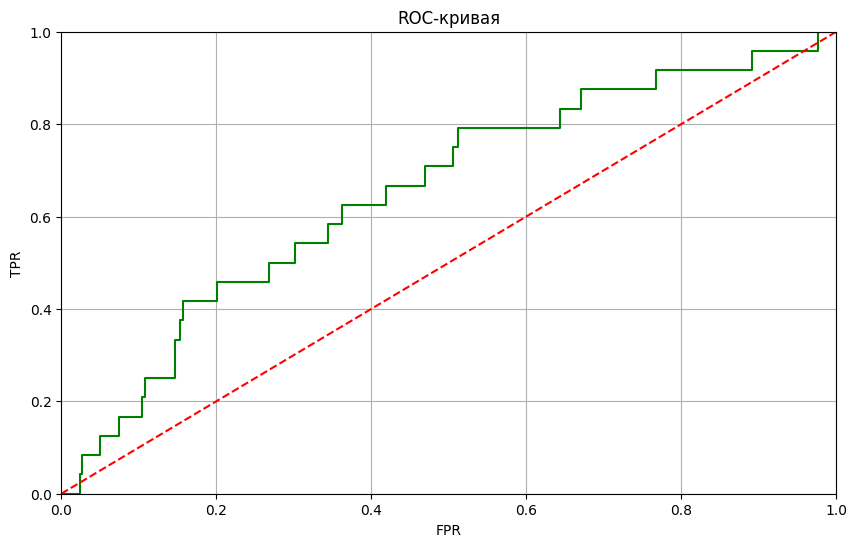

Оптимальный порог: 0.00041

Test Accuracy: 0.4947
Precision: 0.0371
Recall: 0.7500
F1 Score: 0.0707
Ошибка 1 рода: 0.5121
Ошибка 2 рода: 0.2500


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor).to('cpu').numpy()
    y_true = y_test_tensor.to('cpu').numpy()

    fpr, tpr, thresholds = roc_curve(y_true, test_outputs)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='g')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-кривая')
    plt.grid()
    plt.show()

    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]

    print(f'Оптимальный порог: {optimal_threshold:.5f}\n')

    test_preds = (test_outputs > optimal_threshold).astype(float)

    accuracy = accuracy_score(y_true, test_preds)
    precision = precision_score(y_true, test_preds)
    recall = recall_score(y_true, test_preds)
    f1 = f1_score(y_true, test_preds)
    cm = confusion_matrix(y_true, test_preds)
    TN, FP, FN, TP = cm.ravel()
    alpha = FP / (FP + TN)
    beta = 1 - recall

    roc_auc = roc_auc_score(y_true, test_outputs)

print(f'Test Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Ошибка 1 рода: {alpha:.4f}')
print(f'Ошибка 2 рода: {beta:.4f}')

precision = TP/(TP+FP) (доля землетрясений при их предсказании)

recall = TP/(TP+FN) (доля предсказанных землетрясений среди всех)